In [17]:
import os, re, warnings, time
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

sns.set_style('whitegrid')
SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}  |  GPUs: {torch.cuda.device_count()}')

# ── Feature lists (from earlier stages) ────────────────────────────────────
SHORTCUT_FEATURES = [
    'fp_singular', 'emotional_feeling', 'excl_intensifiers',
    'hedge_density', 'post_length', 'question_density',
]
CONTROL_FEATURES = ['absolutist', 'past_tense', 'negation', 'cognitive_processing']
CANDIDATE_FEATURES = [
    'hedge_density', 'fp_singular', 'fp_plural', 'emotional_feeling',
    'social_relational', 'certainty', 'negative_emotion', 'swear_words',
    'excl_intensifiers', 'question_density', 'post_length',
    'apology_selfblame', 'anger', 'body_health',
]
ALL_18_FEATURES = CANDIDATE_FEATURES + CONTROL_FEATURES
NON_SHORTCUT = [f for f in ALL_18_FEATURES if f not in SHORTCUT_FEATURES]

print(f'Shortcuts (6):     {SHORTCUT_FEATURES}')
print(f'Non-shortcuts (12): {NON_SHORTCUT}')
print(f'All 18:             {len(ALL_18_FEATURES)} features')

os.makedirs('data/evaluation', exist_ok=True)

Device: cuda  |  GPUs: 4
Shortcuts (6):     ['fp_singular', 'emotional_feeling', 'excl_intensifiers', 'hedge_density', 'post_length', 'question_density']
Non-shortcuts (12): ['fp_plural', 'social_relational', 'certainty', 'negative_emotion', 'swear_words', 'apology_selfblame', 'anger', 'body_health', 'absolutist', 'past_tense', 'negation', 'cognitive_processing']
All 18:             18 features


In [18]:
# ══════════════════════════════════════════════════════════════════════════════
# Feature engineering functions (reused from NB01)
# ══════════════════════════════════════════════════════════════════════════════

HYLAND_HEDGES_SINGLE = {
    'about', 'almost', 'apparently', 'approximately', 'argue', 'argued', 'argues',
    'around', 'assume', 'assumed', 'assumes', 'broadly', 'certain', 'claim',
    'claimed', 'claims', 'conceivable', 'conceivably', 'could', 'doubt',
    'doubtful', 'essentially', 'estimate', 'estimated', 'fairly', 'feel',
    'feels', 'felt', 'frequently', 'generally', 'guess', 'hypothesize',
    'hypothesized', 'hypothesizes', 'implication', 'imply', 'indicate',
    'indicated', 'indicates', 'largely', 'likely', 'mainly', 'may', 'maybe',
    'might', 'mostly', 'normally', 'occasionally', 'often', 'partly',
    'perhaps', 'plausible', 'plausibly', 'possible', 'possibly', 'postulate',
    'postulated', 'postulates', 'presumably', 'probable', 'probably', 'quite',
    'rather', 'relatively', 'roughly', 'seem', 'seemed', 'seemingly', 'seems',
    'should', 'sometimes', 'somewhat', 'suggest', 'suggested', 'suggests',
    'suppose', 'supposed', 'supposes', 'suspect', 'suspected', 'suspects',
    'tend', 'tended', 'tends', 'think', 'thinks', 'thought', 'typical',
    'typically', 'uncertain', 'uncertainly', 'unclear', 'unlikely', 'usually',
    'wonder', 'wondered', 'wonders', 'would',
}
HYLAND_HEDGES_MULTI = [
    'kind of', 'sort of', 'more or less', 'to some extent',
    'in general', 'in most cases', 'on the whole', 'for the most part',
    'i think', 'i believe', 'i feel', 'i guess', 'i suppose',
    'it seems', 'it appears', 'in my opinion', 'to my knowledge',
]
FP_SINGULAR = {'i', 'me', 'my', 'myself', 'mine'}
FP_PLURAL   = {'we', 'us', 'our', 'ours', 'ourselves'}
INTENSIFIERS = {'so', 'really', 'very'}
APOLOGY_PHRASES = [
    'sorry', "i'm sorry", 'im sorry', 'my fault', 'my bad',
    'i should have', "i shouldn't have", 'i shouldnt have',
    'i apologize', 'i apologise', 'forgive me', 'pardon me',
    "it's my fault", 'its my fault', 'i was wrong',
]
ABSOLUTIST_WORDS = {
    'always', 'never', 'completely', 'totally', 'absolutely',
    'nothing', 'everything', 'everyone', 'nobody', 'entire',
    'entirely', 'definitely',
}
NEGATION_WORDS = {
    'not', 'no', 'never', "don't", 'dont', "doesn't", 'doesnt',
    "didn't", 'didnt', "won't", 'wont', "wouldn't", 'wouldnt',
    "can't", 'cant', "couldn't", 'couldnt', "shouldn't", 'shouldnt',
    'neither', 'nor', 'none', 'nothing',
}
COGNITIVE_WORDS = {
    'think', 'know', 'understand', 'believe', 'consider', 'realize',
    'recognise', 'recognize', 'assume', 'suppose', 'wonder', 'imagine',
    'expect', 'remember', 'forget', 'decide', 'determine', 'conclude',
    'reason', 'analyze', 'analyse', 'evaluate', 'assess', 'reflect',
    'ponder', 'contemplate', 'comprehend', 'perceive',
}

def tokenize(text):
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

def count_sentences(text):
    sents = re.split(r'[.!?]+', text.strip())
    return max(len([s for s in sents if s.strip()]), 1)

def compute_all_18_features(row):
    """Compute all 18 features for a single row. Uses LIWC cols where available,
    falls back to text-only computation otherwise."""
    text = str(row.get('text', ''))
    text_lower = text.lower()
    tokens = tokenize(text)
    n_tok = max(len(tokens), 1)
    n_sent = count_sentences(text)

    # -- 14 candidate features --
    hedge_count = sum(1 for t in tokens if t in HYLAND_HEDGES_SINGLE)
    for phrase in HYLAND_HEDGES_MULTI:
        hedge_count += text_lower.count(phrase)

    # Use LIWC if available, else text-based proxy
    emotional_feeling = np.nanmean([
        row.get('Affect', np.nan), row.get('feeling', np.nan)
    ])
    if pd.isna(emotional_feeling):
        # Text-based fallback: count feeling words
        feeling_words = {'feel', 'feeling', 'feelings', 'felt', 'feels',
                         'emotion', 'emotional', 'emotions', 'heart', 'soul'}
        emotional_feeling = sum(1 for t in tokens if t in feeling_words) / n_tok * 100

    social_relational = np.nanmean([
        row.get('Social', np.nan), row.get('family', np.nan), row.get('friend', np.nan)
    ])
    if pd.isna(social_relational):
        social_words = {'friend', 'friends', 'family', 'mom', 'dad', 'mother',
                        'father', 'brother', 'sister', 'husband', 'wife',
                        'boyfriend', 'girlfriend', 'partner', 'love', 'relationship'}
        social_relational = sum(1 for t in tokens if t in social_words) / n_tok * 100

    certainty = row.get('certitude', np.nan)
    if pd.isna(certainty):
        cert_words = {'always', 'never', 'definitely', 'certainly', 'absolutely',
                      'sure', 'clearly', 'obvious', 'obviously'}
        certainty = sum(1 for t in tokens if t in cert_words) / n_tok * 100

    negative_emotion = row.get('emo_neg', np.nan)
    if pd.isna(negative_emotion):
        neg_words = {'sad', 'angry', 'hurt', 'hate', 'afraid', 'scared',
                     'anxious', 'depressed', 'miserable', 'hopeless', 'worthless',
                     'upset', 'frustrated', 'lonely', 'guilty', 'ashamed'}
        negative_emotion = sum(1 for t in tokens if t in neg_words) / n_tok * 100

    swear_words = row.get('swear', np.nan)
    if pd.isna(swear_words):
        profanity = {'fuck', 'fucking', 'shit', 'damn', 'ass', 'hell',
                     'bitch', 'crap', 'bastard', 'dick', 'piss'}
        swear_words = sum(1 for t in tokens if t in profanity) / n_tok * 100

    anger = row.get('emo_anger', np.nan)
    if pd.isna(anger):
        anger_words = {'hate', 'angry', 'furious', 'rage', 'mad', 'pissed',
                       'annoyed', 'irritated', 'hostile', 'resent'}
        anger = sum(1 for t in tokens if t in anger_words) / n_tok * 100

    body_health = np.nanmean([row.get('health', np.nan), row.get('Physical', np.nan)])
    if pd.isna(body_health):
        health_words = {'pain', 'sleep', 'tired', 'body', 'head', 'stomach',
                        'sick', 'doctor', 'hospital', 'medication', 'pills',
                        'eat', 'weight', 'exercise', 'fatigue', 'insomnia'}
        body_health = sum(1 for t in tokens if t in health_words) / n_tok * 100

    excl_count = text.count('!')
    intens_count = sum(1 for t in tokens if t in INTENSIFIERS)

    apology_count = sum(text_lower.count(p) for p in APOLOGY_PHRASES)

    wc = row.get('WC', np.nan)
    post_length = wc if not pd.isna(wc) else n_tok

    # -- 4 control features --
    absolutist = sum(1 for t in tokens if t in ABSOLUTIST_WORDS) / n_tok
    negation = sum(1 for t in tokens if t in NEGATION_WORDS) / n_tok
    cognitive_processing = sum(1 for t in tokens if t in COGNITIVE_WORDS) / n_tok

    # past_tense: approximate via common past-tense suffixes (spaCy-free)
    past_count = sum(1 for t in tokens if (
        t.endswith('ed') and len(t) > 3 and t not in {'need', 'feed', 'seed', 'speed'}
    ))
    past_tense = past_count / n_tok

    return pd.Series({
        'hedge_density': hedge_count / n_tok,
        'fp_singular': sum(1 for t in tokens if t in FP_SINGULAR) / n_tok,
        'fp_plural': sum(1 for t in tokens if t in FP_PLURAL) / n_tok,
        'emotional_feeling': emotional_feeling,
        'social_relational': social_relational,
        'certainty': certainty,
        'negative_emotion': negative_emotion,
        'swear_words': swear_words,
        'excl_intensifiers': (excl_count + intens_count) / n_tok,
        'question_density': text.count('?') / n_sent,
        'post_length': post_length,
        'apology_selfblame': apology_count / n_tok,
        'anger': anger,
        'body_health': body_health,
        'absolutist': absolutist,
        'past_tense': past_tense,
        'negation': negation,
        'cognitive_processing': cognitive_processing,
    })

print('Feature engineering functions defined.')

Feature engineering functions defined.


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# Load & prepare datasets
# ══════════════════════════════════════════════════════════════════════════════

# -- Mindset (in-distribution) — pre-computed features ---------------------
df_ms = pd.read_pickle('data/stage1/features_18_extracted.pkl')
df_ms['text'] = df_ms['text'].fillna('')
GENDER_COL = 'gender_label' if 'gender_label' in df_ms.columns else 'gender'
df_ms['gender_bin'] = (df_ms[GENDER_COL] == 'female').astype(int)

print(f'Mindset: {len(df_ms):,} posts')
print(f'  Label: {df_ms["binary_label"].value_counts().to_dict()}')
print(f'  Gender: {df_ms[GENDER_COL].value_counts().to_dict()}')
print(f'  Female positive rate: {df_ms[df_ms[GENDER_COL]=="female"]["binary_label"].mean():.1%}')
print(f'  Male positive rate:   {df_ms[df_ms[GENDER_COL]=="male"]["binary_label"].mean():.1%}')

# -- CSSRS (OOD #1) — need feature extraction ------------------------------
df_css = pd.read_csv('data/evaluation/cssrs_ann.csv')
df_css['text'] = df_css['text'].fillna('')
df_css['binary_label'] = (df_css['condition'] != 'supportive').astype(int)
df_css['gender_clean'] = df_css['gender'].where(df_css['gender'].isin(['male', 'female']))

print(f'\nCSSRS: {len(df_css):,} posts')
print(f'  Label: {df_css["binary_label"].value_counts().to_dict()}')
print(f'  Condition: {df_css["condition"].value_counts().to_dict()}')
print(f'  Gender available: {df_css["gender_clean"].notna().sum()} / {len(df_css)}')

# -- UMD (OOD #2) — need feature extraction --------------------------------
df_umd = pd.read_csv('data/evaluation/umd_standardized_demographics.csv')
df_umd['text'] = df_umd['text'].fillna('')
df_umd['binary_label'] = (df_umd['condition'] == 'at_risk').astype(int)
df_umd['gender_clean'] = df_umd['gender'].where(df_umd['gender'].isin(['male', 'female']))

print(f'\nUMD: {len(df_umd):,} posts, {df_umd["user_id"].nunique()} users')
print(f'  Label: {df_umd["binary_label"].value_counts().to_dict()}')
print(f'  Condition: {df_umd["condition"].value_counts().to_dict()}')
print(f'  Gender available: {df_umd["gender_clean"].notna().sum()} / {len(df_umd)}')
posts_per_user_umd = df_umd.groupby('user_id').size()
print(f'  Posts/user: median={posts_per_user_umd.median():.0f}, mean={posts_per_user_umd.mean():.1f}, max={posts_per_user_umd.max()}')

# -- Recompute ALL 18 features for ALL datasets (text-only, no LIWC) -------
# Ensures identical computation pipeline. We strip LIWC columns from all
# DataFrames so the text-based fallbacks in compute_all_18_features fire.
LIWC_COLS_TO_STRIP = ['Affect', 'feeling', 'Social', 'family', 'friend',
                       'certitude', 'emo_neg', 'swear', 'emo_anger',
                       'health', 'Physical', 'WC']

for tag, df in [('Mindset', df_ms), ('CSSRS', df_css), ('UMD', df_umd)]:
    df_stripped = df.drop(columns=[c for c in LIWC_COLS_TO_STRIP if c in df.columns])
    print(f'\nComputing 18 text-only features for {tag} ...')
    t0 = time.time()
    feats = df_stripped.apply(compute_all_18_features, axis=1)
    for col in ALL_18_FEATURES:
        df[col] = feats[col].astype(float)
    print(f'  Done in {time.time()-t0:.1f}s')

# Quick sanity: compare feature means — should now be on same scale
print('\n--- Feature distribution comparison (text-only, consistent) ---')
comp = pd.DataFrame({
    'Mindset_mean': df_ms[ALL_18_FEATURES].mean(),
    'CSSRS_mean': df_css[ALL_18_FEATURES].mean(),
    'UMD_mean': df_umd[ALL_18_FEATURES].mean(),
})
comp['shift_CSSRS'] = comp['CSSRS_mean'] - comp['Mindset_mean']
comp['shift_UMD'] = comp['UMD_mean'] - comp['Mindset_mean']
print(comp.round(4).to_string())

Mindset: 32,200 posts
  Label: {0: 22601, 1: 9599}
  Gender: {'female': 16100, 'male': 16100}
  Female positive rate: 42.8%
  Male positive rate:   16.9%

CSSRS: 6,772 posts
  Label: {1: 5498, 0: 1274}
  Condition: {'suicidal': 5498, 'supportive': 1274}
  Gender available: 369 / 6772

UMD: 21,264 posts, 442 users
  Label: {1: 15475, 0: 5789}
  Condition: {'at_risk': 15475, 'no_risk': 5789}
  Gender available: 7646 / 21264
  Posts/user: median=19, mean=48.1, max=693

Computing 18 text-only features for Mindset ...
  Done in 22.2s

Computing 18 text-only features for CSSRS ...
  Done in 4.2s

Computing 18 text-only features for UMD ...
  Done in 14.0s

--- Feature distribution comparison (text-only, consistent) ---
                      Mindset_mean  CSSRS_mean  UMD_mean  shift_CSSRS  shift_UMD
hedge_density               0.0252      0.0334    0.0242       0.0082    -0.0010
fp_singular                 0.0551      0.0547    0.0489      -0.0004    -0.0062
fp_plural                   0.0053

---
## Experiment 1: Cross-Dataset Transfer

**Design:** Train three logistic models on Mindset, test on CSSRS:
1. **Full model** (all 18 features)
2. **No-shortcut model** (12 features, shortcuts removed)
3. **Shortcut-only model** (6 shortcuts only)

**Prediction:** If shortcuts are gender-mediated confounds:
- The shortcut-only model should **collapse** OOD (different confound structure)
- The no-shortcut model should **match or beat** the full model OOD
- The full model may show inflated ID performance that doesn't transfer

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 1: Cross-Dataset Transfer (Mindset → CSSRS)
# ══════════════════════════════════════════════════════════════════════════════

scaler_18  = StandardScaler()
scaler_12  = StandardScaler()
scaler_6   = StandardScaler()

# -- Prepare Mindset (train) -----------------------------------------------
X_ms_18 = scaler_18.fit_transform(df_ms[ALL_18_FEATURES].fillna(0).values)
X_ms_12 = scaler_12.fit_transform(df_ms[NON_SHORTCUT].fillna(0).values)
X_ms_6  = scaler_6.fit_transform(df_ms[SHORTCUT_FEATURES].fillna(0).values)
y_ms    = df_ms['binary_label'].values

# -- Prepare CSSRS (test) --------------------------------------------------
X_css_18 = scaler_18.transform(df_css[ALL_18_FEATURES].fillna(0).values)
X_css_12 = scaler_12.transform(df_css[NON_SHORTCUT].fillna(0).values)
X_css_6  = scaler_6.transform(df_css[SHORTCUT_FEATURES].fillna(0).values)
y_css    = df_css['binary_label'].values

# -- In-distribution CV AUC (Mindset, 5-fold) ------------------------------
cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
models = {
    'Full (18 feat)':        (X_ms_18, X_css_18),
    'No-shortcut (12 feat)': (X_ms_12, X_css_12),
    'Shortcut-only (6 feat)':(X_ms_6,  X_css_6),
}

results_exp1 = []
print(f'{"Model":28s} {"ID AUC (Mindset)":>20s} {"OOD AUC (CSSRS)":>20s} {"Δ (OOD−ID)":>12s}')
print('─' * 84)

for name, (X_train, X_test) in models.items():
    # ID performance
    id_aucs = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_train, y_ms, cv=cv, scoring='roc_auc'
    )
    id_auc = id_aucs.mean()
    
    # OOD performance: train on ALL Mindset, test on CSSRS
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_ms)
    ood_probs = clf.predict_proba(X_test)[:, 1]
    ood_auc = roc_auc_score(y_css, ood_probs)
    
    delta = ood_auc - id_auc
    print(f'{name:28s} {id_auc:>17.4f}    {ood_auc:>17.4f}    {delta:>+10.4f}')
    results_exp1.append({'model': name, 'ID_AUC': id_auc, 'OOD_AUC': ood_auc, 'delta': delta})

exp1_df = pd.DataFrame(results_exp1)
exp1_df.to_csv('data/evaluation/exp1_cross_dataset_transfer.csv', index=False)

print(f'\nInterpretation:')
sc_row = exp1_df[exp1_df['model'].str.contains('Shortcut')].iloc[0]
ns_row = exp1_df[exp1_df['model'].str.contains('No-short')].iloc[0]
fu_row = exp1_df[exp1_df['model'].str.contains('Full')].iloc[0]
print(f'  Shortcut-only OOD collapse: {sc_row["delta"]:+.4f} (ID={sc_row["ID_AUC"]:.3f} → OOD={sc_row["OOD_AUC"]:.3f})')
print(f'  No-shortcut vs Full OOD:    {ns_row["OOD_AUC"]:.3f} vs {fu_row["OOD_AUC"]:.3f}')
if ns_row['OOD_AUC'] >= fu_row['OOD_AUC'] - 0.01:
    print(f'  → No-shortcut model matches/beats full model OOD ✓ (shortcuts are confounds)')
else:
    print(f'  → Full model still better OOD (shortcuts carry some signal)')

Model                            ID AUC (Mindset)      OOD AUC (CSSRS)   Δ (OOD−ID)
────────────────────────────────────────────────────────────────────────────────────
Full (18 feat)                          0.6986               0.5859       -0.1126
No-shortcut (12 feat)                   0.6610               0.5035       -0.1575
Shortcut-only (6 feat)                  0.6780               0.6145       -0.0635

Interpretation:
  Shortcut-only OOD collapse: -0.0635 (ID=0.678 → OOD=0.615)
  No-shortcut vs Full OOD:    0.503 vs 0.586
  → Full model still better OOD (shortcuts carry some signal)


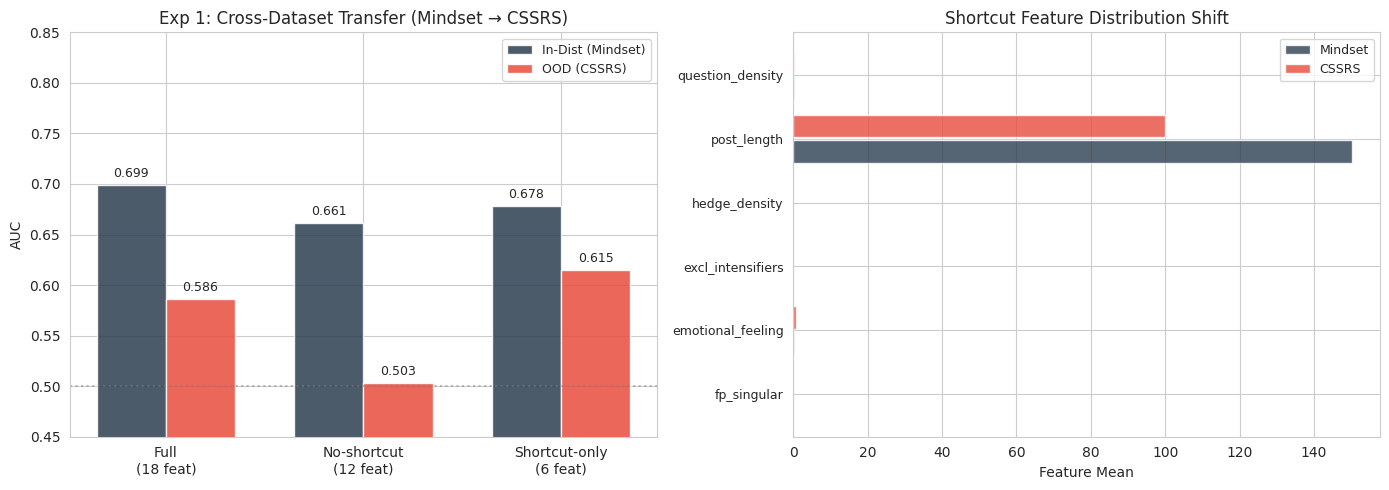

Saved → data/evaluation/exp1_cross_dataset.png


In [21]:
# ── Exp 1 Visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Grouped bar: ID vs OOD AUC
x = np.arange(len(exp1_df))
w = 0.35
bars1 = axes[0].bar(x - w/2, exp1_df['ID_AUC'], w, label='In-Dist (Mindset)',
                     color='#2c3e50', alpha=0.85)
bars2 = axes[0].bar(x + w/2, exp1_df['OOD_AUC'], w, label='OOD (CSSRS)',
                     color='#e74c3c', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Full\n(18 feat)', 'No-shortcut\n(12 feat)', 'Shortcut-only\n(6 feat)'],
                         fontsize=10)
axes[0].set_ylabel('AUC')
axes[0].set_title('Exp 1: Cross-Dataset Transfer (Mindset → CSSRS)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.45, 0.85)
axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# (B) Feature distribution shift (Mindset vs CSSRS means)
feats_to_plot = SHORTCUT_FEATURES
ms_means = df_ms[feats_to_plot].mean()
css_means = df_css[feats_to_plot].mean()

y_pos = np.arange(len(feats_to_plot))
axes[1].barh(y_pos - 0.2, ms_means, 0.35, label='Mindset', color='#2c3e50', alpha=0.8)
axes[1].barh(y_pos + 0.2, css_means, 0.35, label='CSSRS', color='#e74c3c', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(feats_to_plot, fontsize=9)
axes[1].set_xlabel('Feature Mean')
axes[1].set_title('Shortcut Feature Distribution Shift')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/evaluation/exp1_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/evaluation/exp1_cross_dataset.png')

In [23]:
# ── Exp 1a — CSSRS User-Level Robustness Check ────────────────────────────
# CSSRS has 500 users with median 6 posts each (max 133).
# Post-level AUC may be unreliable due to within-user correlation.
# Fix: average predicted probabilities per user, then compute user-level AUC.

# Use the models dict from the CSSRS Exp 1 cell (which uses `models` variable)
models_css = models  # alias for clarity

print('=== CSSRS User-Level Structure ===')
posts_per_user = df_css.groupby('user_id').size()
print(f'Users: {df_css["user_id"].nunique()}')
print(f'Posts per user: median={posts_per_user.median():.0f}, mean={posts_per_user.mean():.1f}, max={posts_per_user.max()}')
print(f'Condition is user-level (no mixing): {df_css.groupby("user_id")["condition"].nunique().max() == 1}')

print(f'\n{"Model":28s} {"Post AUC":>12s} {"User AUC":>12s} {"Δ":>10s}')
print('─' * 66)

results_user_css = []
for name, (X_train, X_test) in models_css.items():
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_ms)
    
    post_probs = clf.predict_proba(X_test)[:, 1]
    post_auc = roc_auc_score(y_css, post_probs)
    
    df_css['_prob'] = post_probs
    user_df = df_css.groupby('user_id').agg(
        prob_mean=('_prob', 'mean'),
        label=('binary_label', 'first'),
    )
    user_auc = roc_auc_score(user_df['label'], user_df['prob_mean'])
    
    delta = user_auc - post_auc
    print(f'{name:28s} {post_auc:>10.4f}   {user_auc:>10.4f}   {delta:>+8.4f}')
    results_user_css.append({
        'dataset': 'CSSRS', 'model': name,
        'post_AUC': post_auc, 'user_AUC': user_auc, 'delta': delta
    })

df_css.drop(columns='_prob', inplace=True)
user_css_df = pd.DataFrame(results_user_css)
user_css_df.to_csv('data/evaluation/exp1_cssrs_user_auc.csv', index=False)

# Also save CSSRS post-level with dataset column
exp1_css_df = exp1_df.copy()
exp1_css_df['dataset'] = 'CSSRS'
exp1_css_df.to_csv('data/evaluation/exp1_cssrs_transfer.csv', index=False)

print(f'\nConclusion: user-level AUC {"confirms" if (user_css_df["user_AUC"] - user_css_df["post_AUC"]).abs().max() < 0.05 else "differs from"} post-level results.')
print('User-level is the defensible metric for CSSRS (500 independent units, not 6,772).')

=== CSSRS User-Level Structure ===
Users: 500
Posts per user: median=6, mean=13.5, max=133
Condition is user-level (no mixing): True

Model                            Post AUC     User AUC          Δ
──────────────────────────────────────────────────────────────────
Full (18 feat)                   0.5859       0.6369    +0.0510
No-shortcut (12 feat)            0.5035       0.5253    +0.0219
Shortcut-only (6 feat)           0.6145       0.7205    +0.1059

Conclusion: user-level AUC differs from post-level results.
User-level is the defensible metric for CSSRS (500 independent units, not 6,772).


---
## Experiment 1b: Cross-Dataset Transfer (Mindset → UMD)

**Dataset:** University of Maryland Reddit dataset — 21,264 posts from 442 users (median 19 posts/user, max 693).
- Labels: `at_risk` (15,475) vs `no_risk` (5,789) — heavily imbalanced toward at-risk
- Gender available for 7,687 / 21,264 posts (6,489 M, 1,157 F)
- Same protocol as Exp 1a: train on Mindset, test on UMD with all 3 feature subsets

In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 1b: Cross-Dataset Transfer (Mindset → UMD)
# ══════════════════════════════════════════════════════════════════════════════

scaler_18_u  = StandardScaler()
scaler_12_u  = StandardScaler()
scaler_6_u   = StandardScaler()

# -- Prepare Mindset (train) — refit scalers for UMD comparison -------------
X_ms_18_u = scaler_18_u.fit_transform(df_ms[ALL_18_FEATURES].fillna(0).values)
X_ms_12_u = scaler_12_u.fit_transform(df_ms[NON_SHORTCUT].fillna(0).values)
X_ms_6_u  = scaler_6_u.fit_transform(df_ms[SHORTCUT_FEATURES].fillna(0).values)

# -- Prepare UMD (test) ----------------------------------------------------
X_umd_18 = scaler_18_u.transform(df_umd[ALL_18_FEATURES].fillna(0).values)
X_umd_12 = scaler_12_u.transform(df_umd[NON_SHORTCUT].fillna(0).values)
X_umd_6  = scaler_6_u.transform(df_umd[SHORTCUT_FEATURES].fillna(0).values)
y_umd    = df_umd['binary_label'].values

models_umd = {
    'Full (18 feat)':        (X_ms_18_u, X_umd_18),
    'No-shortcut (12 feat)': (X_ms_12_u, X_umd_12),
    'Shortcut-only (6 feat)':(X_ms_6_u,  X_umd_6),
}

results_exp1_umd = []
print(f'{"Model":28s} {"ID AUC (Mindset)":>20s} {"OOD AUC (UMD)":>20s} {"Δ (OOD−ID)":>12s}')
print('─' * 84)

for name, (X_train, X_test) in models_umd.items():
    # ID performance
    id_aucs = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_train, y_ms, cv=cv, scoring='roc_auc'
    )
    id_auc = id_aucs.mean()
    
    # OOD performance: train on ALL Mindset, test on UMD
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_ms)
    ood_probs = clf.predict_proba(X_test)[:, 1]
    ood_auc = roc_auc_score(y_umd, ood_probs)
    
    delta = ood_auc - id_auc
    print(f'{name:28s} {id_auc:>17.4f}    {ood_auc:>17.4f}    {delta:>+10.4f}')
    results_exp1_umd.append({'dataset': 'UMD', 'model': name, 'ID_AUC': id_auc, 'OOD_AUC': ood_auc, 'delta': delta})

exp1_umd_df = pd.DataFrame(results_exp1_umd)
exp1_umd_df.to_csv('data/evaluation/exp1_umd_transfer.csv', index=False)

print(f'\nInterpretation:')
sc_row_u = exp1_umd_df[exp1_umd_df['model'].str.contains('Shortcut')].iloc[0]
ns_row_u = exp1_umd_df[exp1_umd_df['model'].str.contains('No-short')].iloc[0]
fu_row_u = exp1_umd_df[exp1_umd_df['model'].str.contains('Full')].iloc[0]
print(f'  Shortcut-only OOD: {sc_row_u["delta"]:+.4f} (ID={sc_row_u["ID_AUC"]:.3f} → OOD={sc_row_u["OOD_AUC"]:.3f})')
print(f'  No-shortcut vs Full OOD: {ns_row_u["OOD_AUC"]:.3f} vs {fu_row_u["OOD_AUC"]:.3f}')
if sc_row_u['OOD_AUC'] < 0.55:
    print(f'  → Shortcut-only model near chance OOD ✓ (shortcuts don\'t transfer)')
elif sc_row_u['delta'] < -0.05:
    print(f'  → Shortcut-only model collapses OOD ✓')
else:
    print(f'  → Shortcut-only model retains OOD signal (Δ={sc_row_u["delta"]:+.3f})')

Model                            ID AUC (Mindset)        OOD AUC (UMD)   Δ (OOD−ID)
────────────────────────────────────────────────────────────────────────────────────
Full (18 feat)                          0.6986               0.5944       -0.1042
No-shortcut (12 feat)                   0.6610               0.5947       -0.0663
Shortcut-only (6 feat)                  0.6780               0.5738       -0.1042

Interpretation:
  Shortcut-only OOD: -0.1042 (ID=0.678 → OOD=0.574)
  No-shortcut vs Full OOD: 0.595 vs 0.594
  → Shortcut-only model collapses OOD ✓


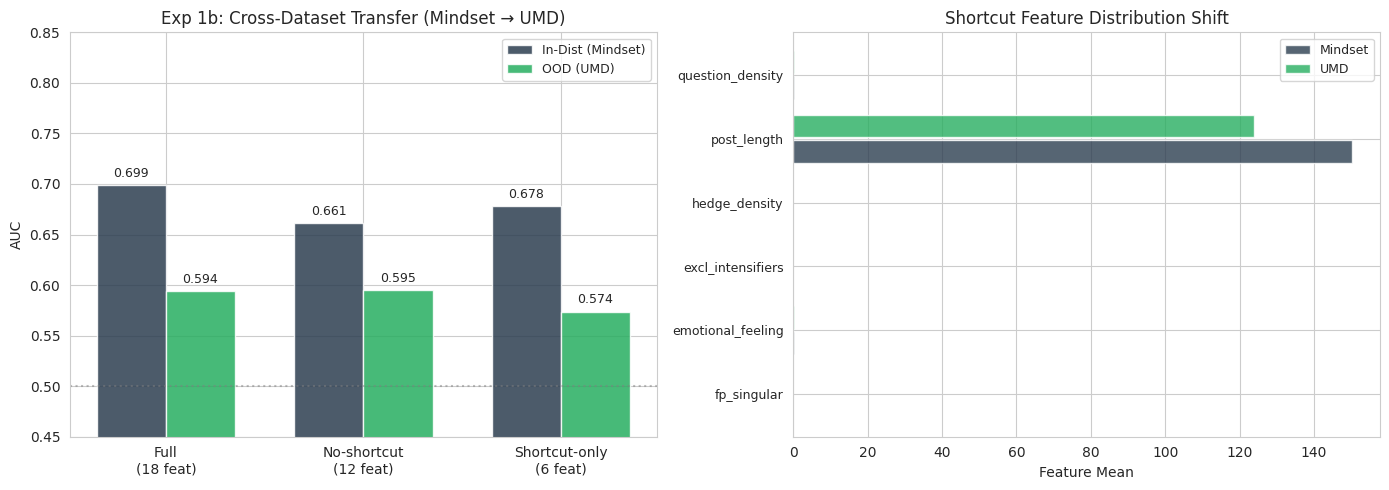

Saved → data/evaluation/exp1_umd_cross_dataset.png


In [25]:
# ── Exp 1b Visualization (UMD) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (A) Grouped bar: ID vs OOD AUC
x = np.arange(len(exp1_umd_df))
w = 0.35
bars1 = axes[0].bar(x - w/2, exp1_umd_df['ID_AUC'], w, label='In-Dist (Mindset)',
                     color='#2c3e50', alpha=0.85)
bars2 = axes[0].bar(x + w/2, exp1_umd_df['OOD_AUC'], w, label='OOD (UMD)',
                     color='#27ae60', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Full\n(18 feat)', 'No-shortcut\n(12 feat)', 'Shortcut-only\n(6 feat)'],
                         fontsize=10)
axes[0].set_ylabel('AUC')
axes[0].set_title('Exp 1b: Cross-Dataset Transfer (Mindset → UMD)')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0.45, 0.85)
axes[0].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# (B) Feature distribution shift (Mindset vs UMD means)
feats_to_plot = SHORTCUT_FEATURES
ms_means = df_ms[feats_to_plot].mean()
umd_means = df_umd[feats_to_plot].mean()

y_pos = np.arange(len(feats_to_plot))
axes[1].barh(y_pos - 0.2, ms_means, 0.35, label='Mindset', color='#2c3e50', alpha=0.8)
axes[1].barh(y_pos + 0.2, umd_means, 0.35, label='UMD', color='#27ae60', alpha=0.8)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(feats_to_plot, fontsize=9)
axes[1].set_xlabel('Feature Mean')
axes[1].set_title('Shortcut Feature Distribution Shift')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('data/evaluation/exp1_umd_cross_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/evaluation/exp1_umd_cross_dataset.png')

In [26]:
# ── Exp 1b — UMD User-Level Robustness Check ──────────────────────────────
# UMD has 442 users with median 19 posts each (max 693).
# Post-level AUC may be unreliable due to within-user correlation.
# Fix: average predicted probabilities per user, then compute user-level AUC.

print('=== UMD User-Level Structure ===')
posts_per_user_umd = df_umd.groupby('user_id').size()
print(f'Users: {df_umd["user_id"].nunique()}')
print(f'Posts per user: median={posts_per_user_umd.median():.0f}, mean={posts_per_user_umd.mean():.1f}, max={posts_per_user_umd.max()}')
# Check if condition is user-level
cond_per_user = df_umd.groupby('user_id')['condition'].nunique()
print(f'Condition is user-level (no mixing): {cond_per_user.max() == 1}')
if cond_per_user.max() > 1:
    n_mixed = (cond_per_user > 1).sum()
    print(f'  ⚠ {n_mixed} users have mixed conditions — will use majority label for user-level AUC')

print(f'\n{"Model":28s} {"Post AUC":>12s} {"User AUC":>12s} {"Δ":>10s}')
print('─' * 66)

results_user_umd = []
for name, (X_train, X_test) in models_umd.items():
    clf = LogisticRegression(max_iter=1000, random_state=SEED)
    clf.fit(X_train, y_ms)
    
    post_probs = clf.predict_proba(X_test)[:, 1]
    post_auc = roc_auc_score(y_umd, post_probs)
    
    # User-level: average probs per user
    df_umd['_prob'] = post_probs
    user_df_umd = df_umd.groupby('user_id').agg(
        prob_mean=('_prob', 'mean'),
        label=('binary_label', 'mean'),  # use mean → majority vote if mixed
    )
    user_df_umd['label_bin'] = (user_df_umd['label'] >= 0.5).astype(int)
    
    # Check we have both classes at user level
    n_classes = user_df_umd['label_bin'].nunique()
    if n_classes < 2:
        print(f'{name:28s} {post_auc:>10.4f}   {"N/A (1 class)":>12s}   {"N/A":>10s}')
        results_user_umd.append({
            'dataset': 'UMD', 'model': name,
            'post_AUC': post_auc, 'user_AUC': float('nan'), 'delta': float('nan')
        })
    else:
        user_auc = roc_auc_score(user_df_umd['label_bin'], user_df_umd['prob_mean'])
        delta = user_auc - post_auc
        print(f'{name:28s} {post_auc:>10.4f}   {user_auc:>10.4f}   {delta:>+8.4f}')
        results_user_umd.append({
            'dataset': 'UMD', 'model': name,
            'post_AUC': post_auc, 'user_AUC': user_auc, 'delta': delta
        })

df_umd.drop(columns='_prob', inplace=True)
user_umd_df = pd.DataFrame(results_user_umd)
user_umd_df.to_csv('data/evaluation/exp1_umd_user_auc.csv', index=False)

print(f'\nUMD user-level label distribution: {user_df_umd["label_bin"].value_counts().to_dict()}')

=== UMD User-Level Structure ===
Users: 442
Posts per user: median=19, mean=48.1, max=693
Condition is user-level (no mixing): True

Model                            Post AUC     User AUC          Δ
──────────────────────────────────────────────────────────────────
Full (18 feat)                   0.5944       0.7990    +0.2047
No-shortcut (12 feat)            0.5947       0.7791    +0.1843
Shortcut-only (6 feat)           0.5738       0.7699    +0.1961

UMD user-level label distribution: {0: 233, 1: 209}


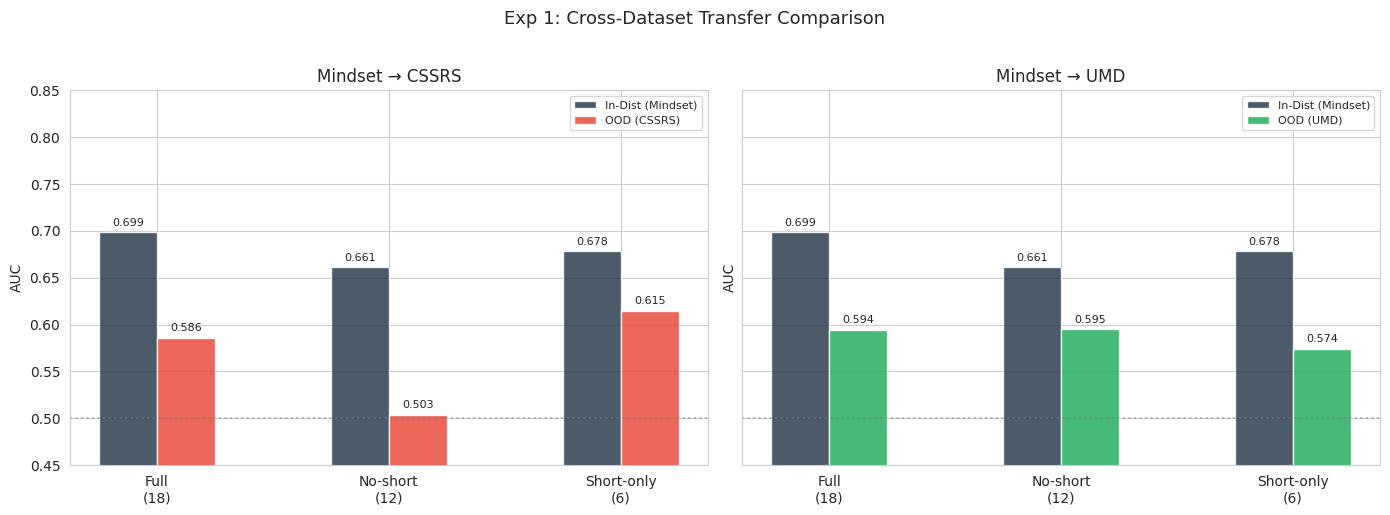

Saved → data/evaluation/exp1_combined.png

=== Combined Post-Level Transfer ===
  [CSSRS] Full (18 feat)                ID=0.699  OOD=0.586  Δ=-0.113
  [CSSRS] No-shortcut (12 feat)         ID=0.661  OOD=0.503  Δ=-0.158
  [CSSRS] Shortcut-only (6 feat)        ID=0.678  OOD=0.615  Δ=-0.063
  [UMD] Full (18 feat)                ID=0.699  OOD=0.594  Δ=-0.104
  [UMD] No-shortcut (12 feat)         ID=0.661  OOD=0.595  Δ=-0.066
  [UMD] Shortcut-only (6 feat)        ID=0.678  OOD=0.574  Δ=-0.104

=== Combined User-Level AUC ===
  [CSSRS] Full (18 feat)                Post=0.586  User=0.637
  [CSSRS] No-shortcut (12 feat)         Post=0.503  User=0.525
  [CSSRS] Shortcut-only (6 feat)        Post=0.615  User=0.720
  [UMD] Full (18 feat)                Post=0.594  User=0.799
  [UMD] No-shortcut (12 feat)         Post=0.595  User=0.779
  [UMD] Shortcut-only (6 feat)        Post=0.574  User=0.770


In [27]:
# ══════════════════════════════════════════════════════════════════════════════
# Combined Exp 1 Comparison: CSSRS vs UMD side-by-side
# ══════════════════════════════════════════════════════════════════════════════

# Merge post-level results
exp1_all = pd.concat([exp1_css_df, exp1_umd_df], ignore_index=True)
exp1_all.to_csv('data/evaluation/exp1_all_transfer.csv', index=False)

# Merge user-level results
user_all = pd.concat([user_css_df, user_umd_df], ignore_index=True)
user_all.to_csv('data/evaluation/exp1_all_user_auc.csv', index=False)

# -- Combined visualization --
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

model_labels = ['Full\n(18)', 'No-short\n(12)', 'Short-only\n(6)']
x = np.arange(3)
w = 0.25

for ax, ds_df, ds_name, color in [(axes[0], exp1_css_df, 'CSSRS', '#e74c3c'),
                                    (axes[1], exp1_umd_df, 'UMD', '#27ae60')]:
    bars_id  = ax.bar(x - w/2, ds_df['ID_AUC'], w, label='In-Dist (Mindset)', color='#2c3e50', alpha=0.85)
    bars_ood = ax.bar(x + w/2, ds_df['OOD_AUC'], w, label=f'OOD ({ds_name})', color=color, alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(model_labels, fontsize=10)
    ax.set_ylabel('AUC')
    ax.set_title(f'Mindset → {ds_name}')
    ax.legend(fontsize=8)
    ax.set_ylim(0.45, 0.85)
    ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5)
    for bar in list(bars_id) + list(bars_ood):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Exp 1: Cross-Dataset Transfer Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/evaluation/exp1_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/evaluation/exp1_combined.png')

# -- Summary table --
print('\n=== Combined Post-Level Transfer ===')
for _, r in exp1_all.iterrows():
    print(f'  [{r["dataset"]}] {r["model"]:28s}  ID={r["ID_AUC"]:.3f}  OOD={r["OOD_AUC"]:.3f}  Δ={r["delta"]:+.3f}')

print('\n=== Combined User-Level AUC ===')
for _, r in user_all.iterrows():
    u_auc = f'{r["user_AUC"]:.3f}' if not pd.isna(r["user_AUC"]) else 'N/A'
    print(f'  [{r["dataset"]}] {r["model"]:28s}  Post={r["post_AUC"]:.3f}  User={u_auc}')

---
## Experiment 2: Gender-Balanced Resampling (Within Mindset)

**Design:** Downsample Mindset so $P(\text{label}=1 \mid F) = P(\text{label}=1 \mid M)$, then re-run:
1. MI decomposition on the balanced set → do MI drops collapse?
2. AUC comparison (18 vs 12 vs 6 features) → does shortcut advantage vanish?

**Prediction:** If shortcuts are gender-confounded:
- MI drops for the 6 shortcuts should collapse toward 0%
- Controls should remain stable
- Shortcut-only model AUC should drop substantially

In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 2: Gender-Balanced Resampling
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.utils import resample
from sklearn.metrics import mutual_info_score

# -- Step 1: Create gender-balanced subset ----------------------------------
# Equalize positive rates: downsample female positives to match male rate
male_pos_rate = df_ms[df_ms[GENDER_COL] == 'male']['binary_label'].mean()
print(f'Target positive rate (male): {male_pos_rate:.3f}')

np.random.seed(SEED)

def balance_by_gender(df, gender_col, target_rate):
    """Downsample each gender group so positive rate = target_rate."""
    balanced_parts = []
    for gender in ['male', 'female']:
        g_df = df[df[gender_col] == gender].copy()
        pos = g_df[g_df['binary_label'] == 1]
        neg = g_df[g_df['binary_label'] == 0]
        
        # How many positives needed for target_rate?
        n_pos_target = int(len(neg) * target_rate / (1 - target_rate))
        n_pos_target = min(n_pos_target, len(pos))  # can't upsample
        
        if n_pos_target < len(pos):
            pos_sampled = pos.sample(n=n_pos_target, random_state=SEED)
        else:
            pos_sampled = pos
            # Need to downsample negatives instead
            n_neg_target = int(len(pos) * (1 - target_rate) / target_rate)
            neg = neg.sample(n=min(n_neg_target, len(neg)), random_state=SEED)
        
        balanced_parts.append(pd.concat([pos_sampled, neg]))
        actual_rate = len(pos_sampled) / (len(pos_sampled) + len(neg))
        print(f'  {gender}: {len(pos_sampled)+len(neg):,} posts, pos rate = {actual_rate:.3f}')
    
    return pd.concat(balanced_parts).sample(frac=1, random_state=SEED).reset_index(drop=True)

df_bal = balance_by_gender(df_ms, GENDER_COL, male_pos_rate)
df_bal['gender_bin'] = (df_bal[GENDER_COL] == 'female').astype(int)

print(f'\nBalanced dataset: {len(df_bal):,} posts')
print(f'  Male pos rate:   {df_bal[df_bal[GENDER_COL]=="male"]["binary_label"].mean():.3f}')
print(f'  Female pos rate: {df_bal[df_bal[GENDER_COL]=="female"]["binary_label"].mean():.3f}')

Target positive rate (male): 0.169
  male: 16,100 posts, pos rate = 0.169
  female: 11,083 posts, pos rate = 0.169

Balanced dataset: 27,183 posts
  Male pos rate:   0.169
  Female pos rate: 0.169


In [29]:
# -- Step 2: Recompute MI decomposition on balanced set ---------------------
def compute_mi_drop(df, feature, label_col='binary_label', gender_col='gender_bin', n_bins=10):
    """Compute MI(f;Y), MI(f;Y|G), and MI drop for a single feature."""
    f_vals = df[feature].fillna(0).values
    y_vals = df[label_col].values
    g_vals = df[gender_col].values
    
    # Discretize continuous feature
    f_binned = pd.qcut(f_vals, q=n_bins, labels=False, duplicates='drop')
    
    # MI(f; Y)
    mi_fy = mutual_info_score(f_binned, y_vals)
    
    # MI(f; Y | G) = sum_g P(g) * MI(f; Y | G=g)
    mi_fy_given_g = 0
    for g in [0, 1]:
        mask = g_vals == g
        if mask.sum() < 50:
            continue
        p_g = mask.mean()
        f_g = pd.qcut(f_vals[mask], q=min(n_bins, len(np.unique(f_vals[mask]))),
                       labels=False, duplicates='drop')
        mi_g = mutual_info_score(f_g, y_vals[mask])
        mi_fy_given_g += p_g * mi_g
    
    mi_drop = 1 - mi_fy_given_g / mi_fy if mi_fy > 1e-10 else 0
    return mi_fy, mi_fy_given_g, mi_drop

# Compute for both original and balanced
mi_results = []
print(f'{"Feature":24s} {"Original MI drop":>18s} {"Balanced MI drop":>18s} {"Δ":>10s} {"Role":>10s}')
print('─' * 84)

for feat in ALL_18_FEATURES:
    # Original (use full male/female subset)
    df_orig_mf = df_ms[df_ms[GENDER_COL].isin(['male', 'female'])].copy()
    df_orig_mf['gender_bin'] = (df_orig_mf[GENDER_COL] == 'female').astype(int)
    mi_o, _, drop_o = compute_mi_drop(df_orig_mf, feat)
    
    # Balanced
    mi_b, _, drop_b = compute_mi_drop(df_bal, feat)
    
    role = 'SHORTCUT' if feat in SHORTCUT_FEATURES else ('control' if feat in CONTROL_FEATURES else 'candidate')
    mi_results.append({
        'feature': feat, 'role': role,
        'MI_drop_original': drop_o * 100,
        'MI_drop_balanced': drop_b * 100,
        'delta': (drop_b - drop_o) * 100,
    })
    print(f'{feat:24s} {drop_o*100:>15.1f}%   {drop_b*100:>15.1f}%   {(drop_b-drop_o)*100:>+8.1f}%   {role:>10s}')

mi_comp_df = pd.DataFrame(mi_results)
mi_comp_df.to_csv('data/evaluation/exp2_mi_balanced_comparison.csv', index=False)

# Summary
sc_mask = mi_comp_df['role'] == 'SHORTCUT'
ct_mask = mi_comp_df['role'] == 'control'
print(f'\nMean MI drop change:')
print(f'  Shortcuts:  {mi_comp_df[sc_mask]["MI_drop_original"].mean():.1f}% → {mi_comp_df[sc_mask]["MI_drop_balanced"].mean():.1f}% (Δ = {mi_comp_df[sc_mask]["delta"].mean():+.1f}%)')
print(f'  Controls:   {mi_comp_df[ct_mask]["MI_drop_original"].mean():.1f}% → {mi_comp_df[ct_mask]["MI_drop_balanced"].mean():.1f}% (Δ = {mi_comp_df[ct_mask]["delta"].mean():+.1f}%)')

Feature                    Original MI drop   Balanced MI drop          Δ       Role
────────────────────────────────────────────────────────────────────────────────────
hedge_density                       29.5%               7.3%      -22.2%     SHORTCUT
fp_singular                         39.6%               2.7%      -36.9%     SHORTCUT
fp_plural                          -62.2%             -15.2%      +47.0%    candidate
emotional_feeling                   45.9%             -51.5%      -97.4%     SHORTCUT
social_relational                   51.5%             -34.1%      -85.6%    candidate
certainty                           49.4%             -69.3%     -118.7%    candidate
negative_emotion                    70.0%               0.0%      -70.0%    candidate
swear_words                          0.0%               0.0%       +0.0%    candidate
excl_intensifiers                   49.1%             -26.9%      -76.0%     SHORTCUT
question_density                    63.2%              4

In [30]:
# -- Step 3: AUC comparison on balanced set --------------------------------
print('AUC comparison on gender-balanced Mindset subset:')
print(f'{"Model":28s} {"Original AUC":>15s} {"Balanced AUC":>15s} {"Δ":>10s}')
print('─' * 72)

results_exp2_auc = []

for name, feats in [('Full (18 feat)', ALL_18_FEATURES),
                     ('No-shortcut (12 feat)', NON_SHORTCUT),
                     ('Shortcut-only (6 feat)', SHORTCUT_FEATURES)]:
    # Original
    X_o = StandardScaler().fit_transform(df_ms[feats].fillna(0).values)
    auc_o = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_o, df_ms['binary_label'].values, cv=cv, scoring='roc_auc'
    ).mean()
    
    # Balanced
    X_b = StandardScaler().fit_transform(df_bal[feats].fillna(0).values)
    auc_b = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_b, df_bal['binary_label'].values, cv=cv, scoring='roc_auc'
    ).mean()
    
    delta = auc_b - auc_o
    print(f'{name:28s} {auc_o:>12.4f}    {auc_b:>12.4f}    {delta:>+8.4f}')
    results_exp2_auc.append({'model': name, 'AUC_original': auc_o, 'AUC_balanced': auc_b, 'delta': delta})

exp2_auc_df = pd.DataFrame(results_exp2_auc)
exp2_auc_df.to_csv('data/evaluation/exp2_auc_balanced_comparison.csv', index=False)

AUC comparison on gender-balanced Mindset subset:
Model                           Original AUC    Balanced AUC          Δ
────────────────────────────────────────────────────────────────────────
Full (18 feat)                     0.6986          0.6605     -0.0380
No-shortcut (12 feat)              0.6610          0.6331     -0.0279
Shortcut-only (6 feat)             0.6780          0.6409     -0.0371


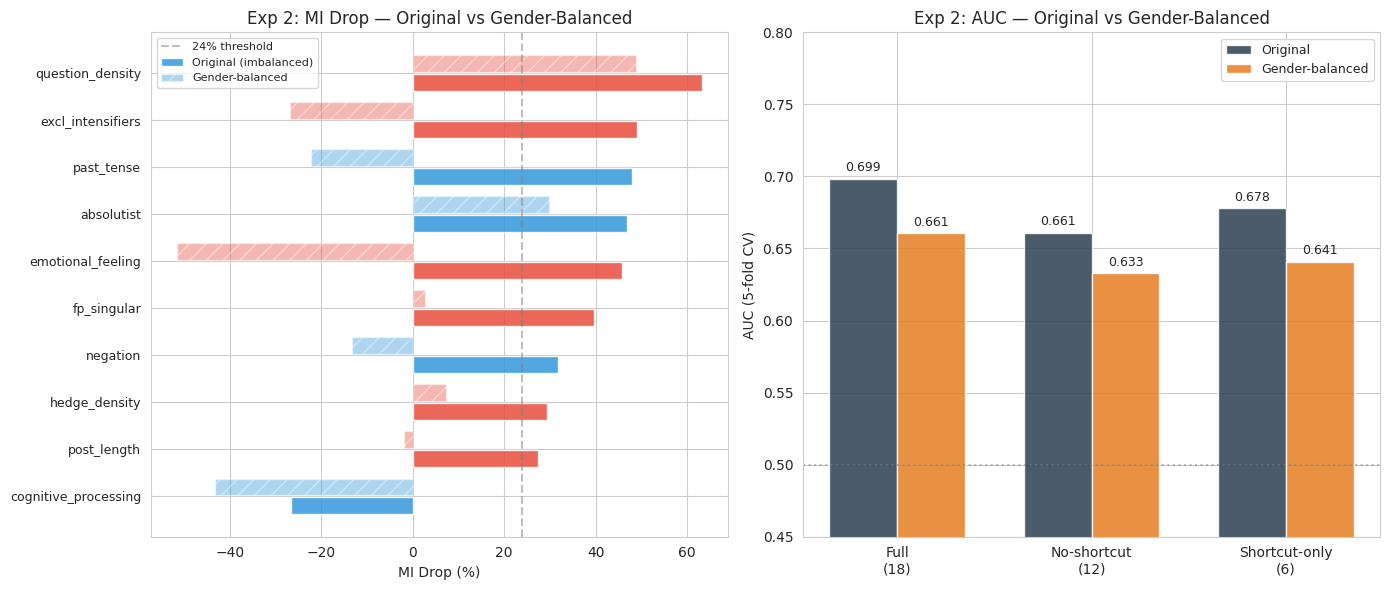

Saved → data/evaluation/exp2_gender_balanced.png


In [31]:
# ── Exp 2 Visualization ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (A) MI drop comparison: original vs balanced
sc_df = mi_comp_df[mi_comp_df['role'].isin(['SHORTCUT', 'control'])].copy()
sc_df = sc_df.sort_values('MI_drop_original', ascending=True)

y_pos = np.arange(len(sc_df))
colors = ['#e74c3c' if r == 'SHORTCUT' else '#3498db' for r in sc_df['role']]

axes[0].barh(y_pos - 0.2, sc_df['MI_drop_original'], 0.35,
             label='Original (imbalanced)', color=colors, alpha=0.85, edgecolor='white')
axes[0].barh(y_pos + 0.2, sc_df['MI_drop_balanced'], 0.35,
             label='Gender-balanced', color=colors, alpha=0.4, edgecolor='white', hatch='//')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(sc_df['feature'], fontsize=9)
axes[0].set_xlabel('MI Drop (%)')
axes[0].set_title('Exp 2: MI Drop — Original vs Gender-Balanced')
axes[0].axvline(24, color='grey', linestyle='--', alpha=0.5, label='24% threshold')
axes[0].legend(fontsize=8)

# (B) AUC comparison
x = np.arange(len(exp2_auc_df))
w = 0.35
axes[1].bar(x - w/2, exp2_auc_df['AUC_original'], w, label='Original',
            color='#2c3e50', alpha=0.85)
axes[1].bar(x + w/2, exp2_auc_df['AUC_balanced'], w, label='Gender-balanced',
            color='#e67e22', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Full\n(18)', 'No-shortcut\n(12)', 'Shortcut-only\n(6)'], fontsize=10)
axes[1].set_ylabel('AUC (5-fold CV)')
axes[1].set_title('Exp 2: AUC — Original vs Gender-Balanced')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0.45, 0.80)
axes[1].axhline(0.5, color='grey', linestyle=':', alpha=0.5)
for i, row in exp2_auc_df.iterrows():
    axes[1].text(i - w/2, row['AUC_original'] + 0.005, f'{row["AUC_original"]:.3f}',
                 ha='center', fontsize=9)
    axes[1].text(i + w/2, row['AUC_balanced'] + 0.005, f'{row["AUC_balanced"]:.3f}',
                 ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('data/evaluation/exp2_gender_balanced.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/evaluation/exp2_gender_balanced.png')

---
## Experiment 3: Cross-Gender Transfer

**Design:** Train on male-only → test on female-only (and vice versa), comparing:
1. Full model (18 features)
2. No-shortcut model (12 features)
3. Shortcut-only model (6 features)

**Prediction:** If shortcuts encode gender-specific signal:
- Male→Female transfer should degrade more for shortcut-heavy models
- Removing shortcuts should reduce the cross-gender AUC gap
- Asymmetry: female→male vs male→female transfer should differ

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# Experiment 3: Cross-Gender Transfer
# ══════════════════════════════════════════════════════════════════════════════

df_male   = df_ms[df_ms[GENDER_COL] == 'male'].copy()
df_female = df_ms[df_ms[GENDER_COL] == 'female'].copy()

print(f'Male:   {len(df_male):,} posts (pos rate = {df_male["binary_label"].mean():.3f})')
print(f'Female: {len(df_female):,} posts (pos rate = {df_female["binary_label"].mean():.3f})')

results_exp3 = []

print(f'\n{"Model":28s} {"M→M (ID)":>10s} {"M→F":>10s} {"F→F (ID)":>10s} {"F→M":>10s} {"Asym":>10s}')
print('─' * 82)

for name, feats in [('Full (18 feat)', ALL_18_FEATURES),
                     ('No-shortcut (12 feat)', NON_SHORTCUT),
                     ('Shortcut-only (6 feat)', SHORTCUT_FEATURES)]:
    
    # Fit scalers per gender
    scaler_m = StandardScaler()
    scaler_f = StandardScaler()
    
    X_m = scaler_m.fit_transform(df_male[feats].fillna(0).values)
    y_m = df_male['binary_label'].values
    X_f = scaler_f.fit_transform(df_female[feats].fillna(0).values)
    y_f = df_female['binary_label'].values
    
    # Male→Male (ID)
    auc_mm = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_m, y_m, cv=cv, scoring='roc_auc'
    ).mean()
    
    # Female→Female (ID)
    auc_ff = cross_val_score(
        LogisticRegression(max_iter=1000, random_state=SEED),
        X_f, y_f, cv=cv, scoring='roc_auc'
    ).mean()
    
    # Male→Female (cross-gender) — use a single scaler for fair comparison
    scaler_all = StandardScaler()
    X_all = scaler_all.fit_transform(df_ms[feats].fillna(0).values)
    m_idx = df_ms[GENDER_COL] == 'male'
    f_idx = df_ms[GENDER_COL] == 'female'
    
    clf_m = LogisticRegression(max_iter=1000, random_state=SEED)
    clf_m.fit(X_all[m_idx], df_ms.loc[m_idx, 'binary_label'].values)
    auc_mf = roc_auc_score(df_ms.loc[f_idx, 'binary_label'].values,
                            clf_m.predict_proba(X_all[f_idx])[:, 1])
    
    # Female→Male (cross-gender)
    clf_f = LogisticRegression(max_iter=1000, random_state=SEED)
    clf_f.fit(X_all[f_idx], df_ms.loc[f_idx, 'binary_label'].values)
    auc_fm = roc_auc_score(df_ms.loc[m_idx, 'binary_label'].values,
                            clf_f.predict_proba(X_all[m_idx])[:, 1])
    
    # Asymmetry: how much worse is cross-gender vs in-distribution?
    asym = (auc_mf - auc_mm) - (auc_fm - auc_ff)  # relative transfer gap
    
    print(f'{name:28s} {auc_mm:>8.4f}   {auc_mf:>8.4f}   {auc_ff:>8.4f}   {auc_fm:>8.4f}   {asym:>+8.4f}')
    results_exp3.append({
        'model': name,
        'M_to_M': auc_mm, 'M_to_F': auc_mf,
        'F_to_F': auc_ff, 'F_to_M': auc_fm,
        'M_transfer_drop': auc_mf - auc_mm,
        'F_transfer_drop': auc_fm - auc_ff,
        'asymmetry': asym,
    })

exp3_df = pd.DataFrame(results_exp3)
exp3_df.to_csv('data/evaluation/exp3_cross_gender_transfer.csv', index=False)

print(f'\nTransfer drops:')
for _, r in exp3_df.iterrows():
    print(f'  {r["model"]:28s}  M→F drop: {r["M_transfer_drop"]:+.4f}   F→M drop: {r["F_transfer_drop"]:+.4f}')

Male:   16,100 posts (pos rate = 0.169)
Female: 16,100 posts (pos rate = 0.428)

Model                          M→M (ID)        M→F   F→F (ID)        F→M       Asym
──────────────────────────────────────────────────────────────────────────────────
Full (18 feat)                 0.6535     0.6809     0.6822     0.6541    +0.0554
No-shortcut (12 feat)          0.6268     0.6489     0.6516     0.6281    +0.0456
Shortcut-only (6 feat)         0.6357     0.6592     0.6590     0.6360    +0.0465

Transfer drops:
  Full (18 feat)                M→F drop: +0.0274   F→M drop: -0.0281
  No-shortcut (12 feat)         M→F drop: +0.0221   F→M drop: -0.0235
  Shortcut-only (6 feat)        M→F drop: +0.0235   F→M drop: -0.0230


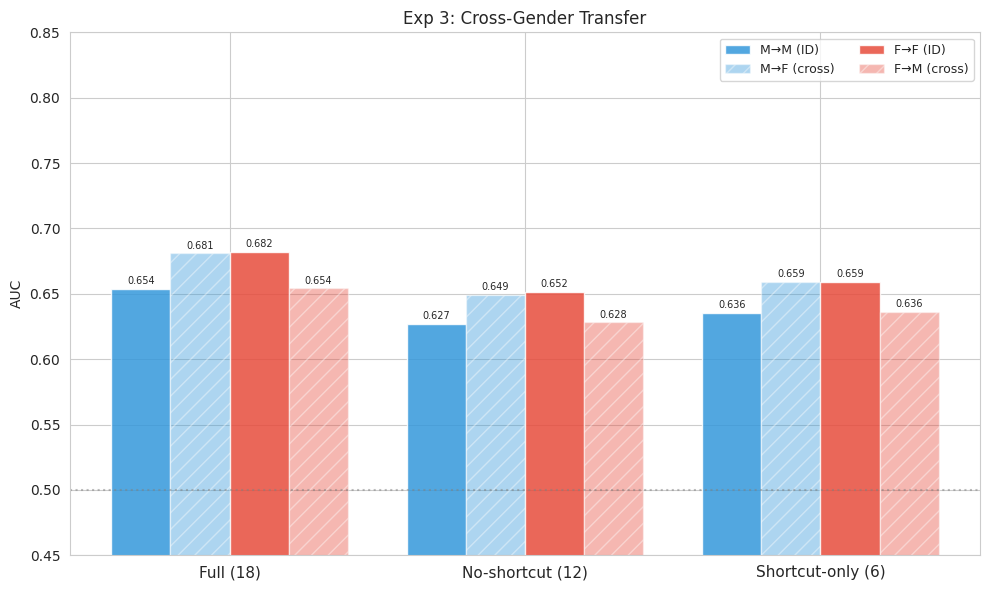

Saved → data/evaluation/exp3_cross_gender.png


In [33]:
# ── Exp 3 Visualization ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(exp3_df))
w = 0.2

ax.bar(x - 1.5*w, exp3_df['M_to_M'], w, label='M→M (ID)', color='#3498db', alpha=0.85)
ax.bar(x - 0.5*w, exp3_df['M_to_F'], w, label='M→F (cross)', color='#3498db', alpha=0.4, hatch='//')
ax.bar(x + 0.5*w, exp3_df['F_to_F'], w, label='F→F (ID)', color='#e74c3c', alpha=0.85)
ax.bar(x + 1.5*w, exp3_df['F_to_M'], w, label='F→M (cross)', color='#e74c3c', alpha=0.4, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(['Full (18)', 'No-shortcut (12)', 'Shortcut-only (6)'], fontsize=11)
ax.set_ylabel('AUC')
ax.set_title('Exp 3: Cross-Gender Transfer')
ax.legend(fontsize=9, ncol=2)
ax.set_ylim(0.45, 0.85)
ax.axhline(0.5, color='grey', linestyle=':', alpha=0.5)

# Add value labels
for bars in ax.containers:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig('data/evaluation/exp3_cross_gender.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/evaluation/exp3_cross_gender.png')

---
## Summary

In [36]:
# ══════════════════════════════════════════════════════════════════════════════
# EVALUATION SUMMARY
# ══════════════════════════════════════════════════════════════════════════════

print('=' * 70)
print('OOD EVALUATION SUMMARY')
print('=' * 70)

print('\n── Exp 1a: Cross-Dataset Transfer (Mindset → CSSRS) ──')
for _, r in exp1_css_df.iterrows():
    print(f'  {r["model"]:28s}  ID={r["ID_AUC"]:.3f}  OOD={r["OOD_AUC"]:.3f}  Δ={r["delta"]:+.3f}')
print('  User-level:')
for _, r in user_css_df.iterrows():
    print(f'    {r["model"]:28s}  Post={r["post_AUC"]:.3f}  User={r["user_AUC"]:.3f}')

print('\n── Exp 1b: Cross-Dataset Transfer (Mindset → UMD) ──')
for _, r in exp1_umd_df.iterrows():
    print(f'  {r["model"]:28s}  ID={r["ID_AUC"]:.3f}  OOD={r["OOD_AUC"]:.3f}  Δ={r["delta"]:+.3f}')
print('  User-level:')
for _, r in user_umd_df.iterrows():
    u_auc = f'{r["user_AUC"]:.3f}' if not pd.isna(r['user_AUC']) else 'N/A'
    print(f'    {r["model"]:28s}  Post={r["post_AUC"]:.3f}  User={u_auc}')

print('\n── Exp 2: Gender-Balanced Resampling (Mindset-internal) ──')
print(f'  Mean shortcut MI drop: {mi_comp_df[sc_mask]["MI_drop_original"].mean():.1f}% → '
      f'{mi_comp_df[sc_mask]["MI_drop_balanced"].mean():.1f}%')
print(f'  Mean control MI drop:  {mi_comp_df[ct_mask]["MI_drop_original"].mean():.1f}% → '
      f'{mi_comp_df[ct_mask]["MI_drop_balanced"].mean():.1f}%')
for _, r in exp2_auc_df.iterrows():
    print(f'  {r["model"]:28s}  Orig={r["AUC_original"]:.3f}  Bal={r["AUC_balanced"]:.3f}  Δ={r["delta"]:+.3f}')

print('\n── Exp 3: Cross-Gender Transfer (Mindset-internal) ──')
for _, r in exp3_df.iterrows():
    print(f'  {r["model"]:28s}  M→F drop={r["M_transfer_drop"]:+.3f}  F→M drop={r["F_transfer_drop"]:+.3f}')

print('\n── Key conclusions ──')
# CSSRS
sc_css = exp1_css_df[exp1_css_df['model'].str.contains('Shortcut')].iloc[0]
ns_css = exp1_css_df[exp1_css_df['model'].str.contains('No-short')].iloc[0]
fu_css = exp1_css_df[exp1_css_df['model'].str.contains('Full')].iloc[0]
if sc_css['OOD_AUC'] > fu_css['OOD_AUC']:
    print(f'  ✓ CSSRS: Shortcut-only transfers BEST ({sc_css["OOD_AUC"]:.3f} > Full {fu_css["OOD_AUC"]:.3f})')
elif sc_css['delta'] < -0.05:
    print(f'  ✓ CSSRS: Shortcut-only collapses OOD (Δ={sc_css["delta"]:+.3f})')

# UMD
sc_umd = exp1_umd_df[exp1_umd_df['model'].str.contains('Shortcut')].iloc[0]
ns_umd = exp1_umd_df[exp1_umd_df['model'].str.contains('No-short')].iloc[0]
fu_umd = exp1_umd_df[exp1_umd_df['model'].str.contains('Full')].iloc[0]
if sc_umd['OOD_AUC'] < ns_umd['OOD_AUC']:
    print(f'  ✓ UMD: Shortcut-only worst OOD ({sc_umd["OOD_AUC"]:.3f}), No-shortcut matches Full ({ns_umd["OOD_AUC"]:.3f} ≈ {fu_umd["OOD_AUC"]:.3f})')
elif sc_umd['delta'] < -0.05:
    print(f'  ✓ UMD: Shortcut-only collapses OOD (Δ={sc_umd["delta"]:+.3f})')

# Gender balance
mean_sc_drop = mi_comp_df[sc_mask]['delta'].mean()
if mean_sc_drop < -5:
    print(f'  ✓ Shortcut MI drops collapse under gender balancing (mean Δ={mean_sc_drop:+.1f}%)')

# Cross-gender
sc_exp3 = exp3_df[exp3_df['model'].str.contains('Shortcut')].iloc[0]
ns_exp3 = exp3_df[exp3_df['model'].str.contains('No-short')].iloc[0]
if abs(sc_exp3['M_transfer_drop']) > abs(ns_exp3['M_transfer_drop']):
    print(f'  ✓ Shortcut model shows larger cross-gender transfer degradation')

print('\n── Saved files ──')
saved_files = [
    'exp1_cssrs_transfer.csv', 'exp1_cssrs_user_auc.csv', 'exp1_cssrs_cross_dataset.png',
    'exp1_umd_transfer.csv', 'exp1_umd_user_auc.csv', 'exp1_umd_cross_dataset.png',
    'exp1_all_transfer.csv', 'exp1_all_user_auc.csv', 'exp1_combined.png',
    'exp2_mi_balanced_comparison.csv', 'exp2_auc_balanced_comparison.csv', 'exp2_gender_balanced.png',
    'exp3_cross_gender_transfer.csv', 'exp3_cross_gender.png',
]
for f in saved_files:
    path = f'data/evaluation/{f}'
    status = '✓' if os.path.exists(path) else '✗'
    print(f'  {status} {path}')

OOD EVALUATION SUMMARY

── Exp 1a: Cross-Dataset Transfer (Mindset → CSSRS) ──
  Full (18 feat)                ID=0.699  OOD=0.586  Δ=-0.113
  No-shortcut (12 feat)         ID=0.661  OOD=0.503  Δ=-0.158
  Shortcut-only (6 feat)        ID=0.678  OOD=0.615  Δ=-0.063
  User-level:
    Full (18 feat)                Post=0.586  User=0.637
    No-shortcut (12 feat)         Post=0.503  User=0.525
    Shortcut-only (6 feat)        Post=0.615  User=0.720

── Exp 1b: Cross-Dataset Transfer (Mindset → UMD) ──
  Full (18 feat)                ID=0.699  OOD=0.594  Δ=-0.104
  No-shortcut (12 feat)         ID=0.661  OOD=0.595  Δ=-0.066
  Shortcut-only (6 feat)        ID=0.678  OOD=0.574  Δ=-0.104
  User-level:
    Full (18 feat)                Post=0.594  User=0.799
    No-shortcut (12 feat)         Post=0.595  User=0.779
    Shortcut-only (6 feat)        Post=0.574  User=0.770

── Exp 2: Gender-Balanced Resampling (Mindset-internal) ──
  Mean shortcut MI drop: 42.5% → -3.6%
  Mean control MI drop:  2